# 18 · GSE232381 · bulk_RNA_seq · heatmap, k-means on both axes

Same matrix as notebook 17: 16 samples × GSE65391 hub genes.

**Layout** (as in endotypes-proteomics): patients are rows, with their dendrogram and clinical
annotations on the left; genes are columns, with their dendrogram, names and WGCNA module colour on top. Within each k-means block, rows and columns are ordered by ward.D2 clustering; that
dendrogram is drawn on the same sides.

 k-means (50 random starts) on genes and on samples separately; for each
axis k is the value from 2 to 8 with the highest mean silhouette width.

**Tests.**
1. Gene clusters against GSE65391 modules: cross-table and adjusted Rand index (ARI).
2. Sample clusters against `nephritis_active`: Fisher's exact test. **A finding** is p < 0.05.
3. Sample k-means clusters against the hierarchical groups of notebook 17: ARI.

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize); library(cluster)})
x    <- readRDS(art("GSE232381", "expression.rds"))
meta <- readRDS(art("GSE232381", "metadata.rds"))
mg   <- read.csv(art("GSE65391", "module_genes.csv"))
hub  <- do.call(rbind, lapply(split(mg, mg$module), function(d) head(d[order(-d$kME), ], 10)))
hub  <- hub[hub$gene %in% rownames(x$E), ]
Z <- t(scale(t(x$E[hub$gene, meta$sample])))
Z <- Z[rowSums(is.na(Z)) == 0, ]; gene_module <- hub$module[match(rownames(Z), hub$gene)]
ari <- function(a, b) {
  tab <- table(a, b); c2 <- function(x) x * (x - 1) / 2
  e <- sum(c2(rowSums(tab))) * sum(c2(colSums(tab))) / c2(sum(tab))
  (sum(c2(tab)) - e) / ((sum(c2(rowSums(tab))) + sum(c2(colSums(tab)))) / 2 - e)
}
choose_k <- function(X, label) {
  set.seed(SEED)
  fits <- lapply(2:8, function(k) kmeans(X, k, nstart = 50, iter.max = 100))
  sil  <- sapply(fits, function(f) mean(silhouette(f$cluster, dist(X))[, "sil_width"]))
  print(data.frame(axis = label, k = 2:8, mean_silhouette = round(sil, 3)))
  fits[[which.max(sil)]]
}
gene_cluster   <- factor(paste0("G", choose_k(Z, "genes")$cluster))
sample_cluster <- factor(paste0("K", choose_k(t(Z), "samples")$cluster))
c(k_genes = nlevels(gene_cluster), k_samples = nlevels(sample_cluster))

   axis k mean_silhouette
1 genes 2           0.232
2 genes 3           0.204
3 genes 4           0.221
4 genes 5           0.233
5 genes 6           0.253
6 genes 7           0.287
7 genes 8           0.302


     axis k mean_silhouette
1 samples 2           0.311
2 samples 3           0.149
3 samples 4           0.148
4 samples 5           0.143
5 samples 6           0.138
6 samples 7           0.127
7 samples 8           0.119


k_genes k_samples 
        8         2

**Result.** Samples: k = 2, the same 2 against 14 split. Genes: k = 8, the edge of the range; the
silhouette was still rising.

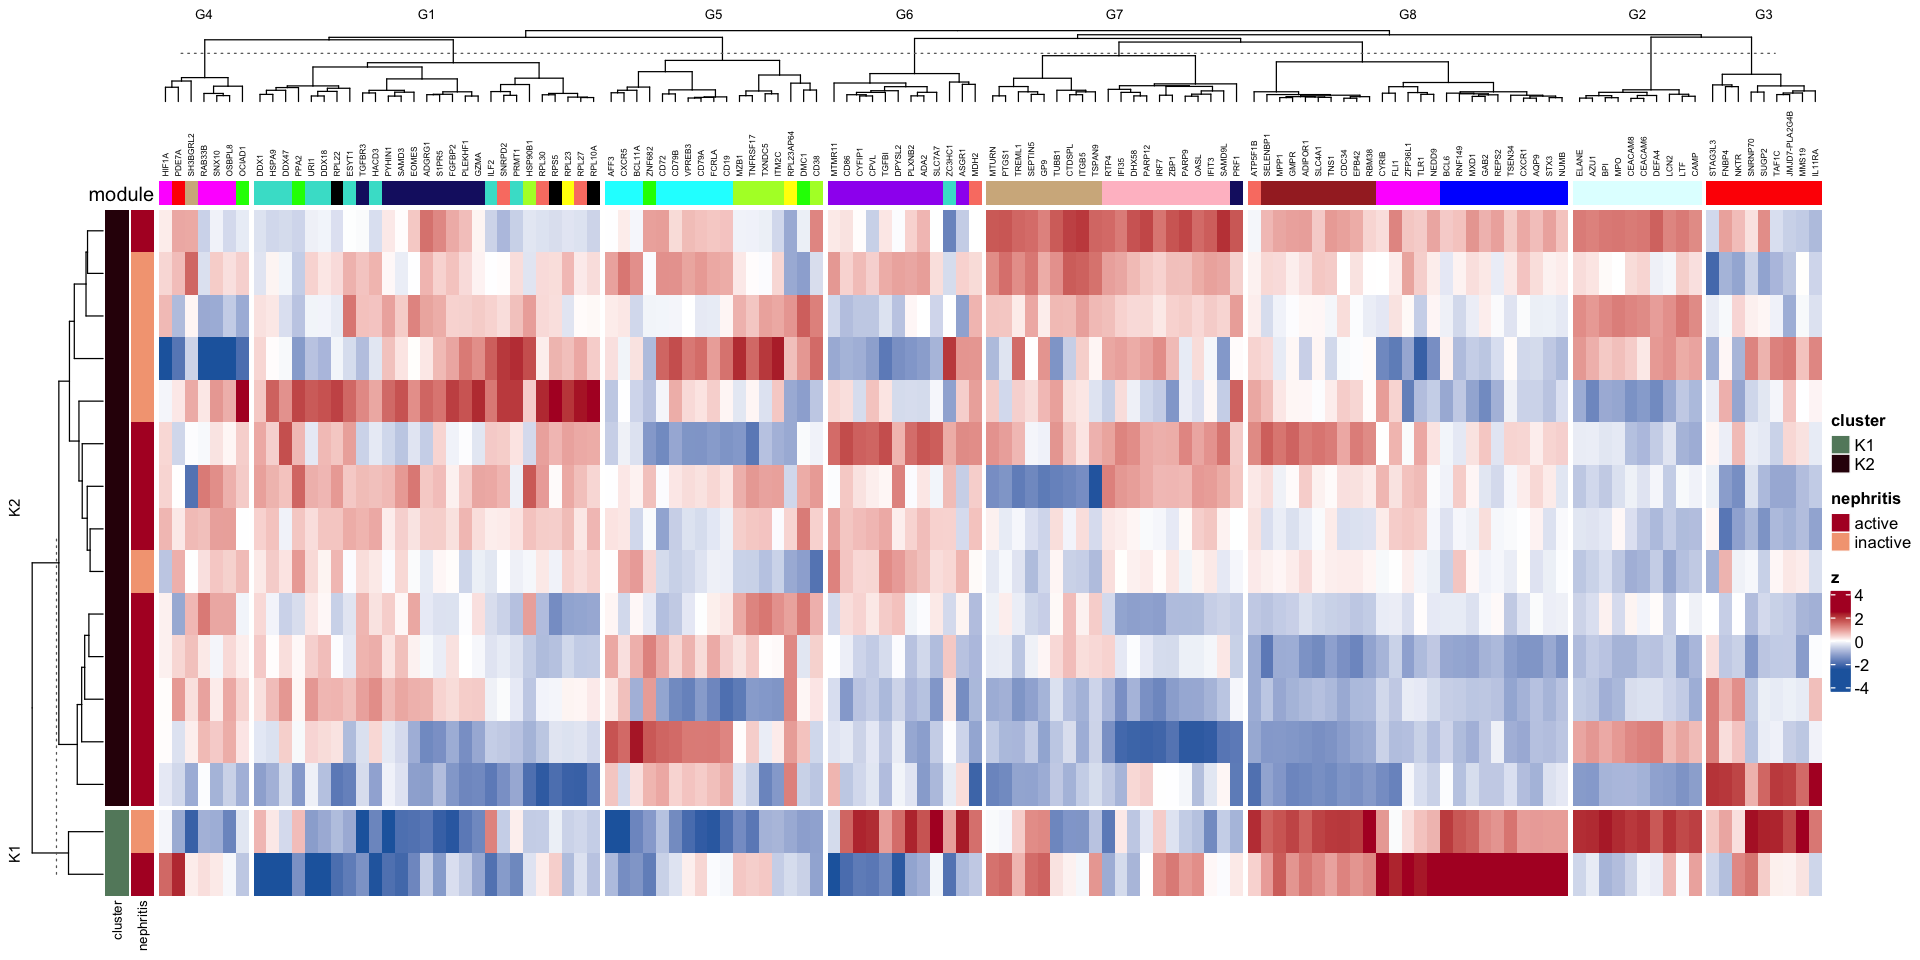

In [2]:
options(repr.plot.width = 16, repr.plot.height = 8)
Heatmap(t(pmin(pmax(Z, -2.5), 2.5)), name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
        row_split = sample_cluster, column_split = gene_cluster,
        clustering_method_rows = "ward.D2", clustering_method_columns = "ward.D2",
        row_dend_side = "left", column_dend_side = "top",
        row_dend_width = unit(15, "mm"), column_dend_height = unit(15, "mm"),
        show_row_names = FALSE, column_names_side = "top", column_names_gp = gpar(fontsize = 5),
        row_title_gp = gpar(fontsize = 9), column_title_gp = gpar(fontsize = 8),
        top_annotation = HeatmapAnnotation(module = gene_module, col = list(module = setNames(unique(gene_module), unique(gene_module))),
                                           show_legend = FALSE, annotation_name_side = "left"),
        left_annotation = rowAnnotation(cluster = sample_cluster, nephritis = ifelse(meta$ln_active == 1, "active", "inactive"),
                                          col = list(nephritis = c(active = "#B2182B", inactive = "#F4A582")),
                                          annotation_name_gp = gpar(fontsize = 8)),
        heatmap_legend_param = list(title = "z"))

**Test 1.** Gene clusters against GSE65391 modules.

In [3]:
table(module = gene_module, gene_cluster = gene_cluster)
c(ARI_gene_clusters_vs_array_modules = round(ari(gene_cluster, gene_module), 3))

              gene_cluster
module         G1 G2 G3 G4 G5 G6 G7 G8
  black         3  0  0  0  0  0  0  0
  blue          0  0  0  0  0  0  0 10
  brown         0  0  0  0  0  0  0  9
  cyan          0  0  0  0  9  0  0  0
  green         1  0  0  1  2  0  0  0
  greenyellow   1  0  0  0  5  0  0  0
  lightcyan     0 10  0  0  0  0  0  0
  magenta       0  0  0  4  0  0  0  5
  midnightblue  9  0  0  0  0  0  1  0
  pink          0  0  0  0  0  0 10  0
  purple        0  0  0  0  0 10  0  0
  red           0  0  9  1  0  0  0  0
  salmon        3  0  0  0  0  1  0  1
  tan           0  0  0  1  0  0  9  0
  turquoise     9  0  0  0  0  1  0  0
  yellow        1  0  0  0  1  0  0  0

ARI_gene_clusters_vs_array_modules 
                             0.475

**Result.** ARI 0.48, the same as within GSE65391 (notebook 08). The hub genes of the pink,
lightcyan, purple, blue and red modules still cluster together here.

**Test 2.** Sample clusters against nephritis activity.

In [4]:
table(cluster = sample_cluster, nephritis = ifelse(meta$ln_active == 1, "active", "inactive"))
fisher.test(table(sample_cluster, meta$ln_active))$p.value

       nephritis
cluster active inactive
     K1      1        1
     K2      9        5

[1] 1

**Result.** No association with nephritis activity (p = 1).

**Test 3.** k-means against the hierarchical groups (same k rule as notebook 17).

In [5]:
hc  <- hclust(dist(t(Z)), method = "ward.D2")
sil <- sapply(2:8, function(k) mean(silhouette(cutree(hc, k), dist(t(Z)))[, "sil_width"]))
hc_group <- factor(paste0("H", cutree(hc, (2:8)[which.max(sil)])))
table(hclust = hc_group, kmeans = sample_cluster)
c(ARI_kmeans_vs_hclust = round(ari(hc_group, sample_cluster), 3))

      kmeans
hclust K1 K2
    H1  0 14
    H2  2  0

ARI_kmeans_vs_hclust 
                   1

**Result.** ARI 1: k-means and hierarchical clustering give the same two groups.